### Here we are building a small agent with two tools as a baseline on HF platform

In [ ]:
from smolagents import CodeAgent, FinalAnswerTool, InferenceClientModel,load_tool
import os

In [ ]:
os.environ["HF_TOKEN"] = "YOUR_TOKEN"

In [7]:
final_answer = FinalAnswerTool()
model = InferenceClientModel(
    max_tokens=2096,
    temperature=0.5,
    model_id='Qwen/Qwen2.5-Coder-32B-Instruct',
    custom_role_conversions=None,)

In [8]:
image_generation_tool = load_tool("agents-course/text-to-image", trust_remote_code=True)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Make a picture of a cat                                                                                         │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

c:\Users\ThinkBook\AppData\Local\Programs\Python\Python312\Lib\site-packages\rich\live.py:231: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  prompt = "A high-res, photorealistic image of a cat sitting on a windowsill, looking outside with a curious      
  expression."                                                                                                     
  image = image_generator(prompt=prompt)                                                                           
  final_answer(image)                                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024 at 0x1C43F79CBC0>

[Step 1: Duration 12.68 seconds| Input tokens: 2,098 | Output tokens: 69]

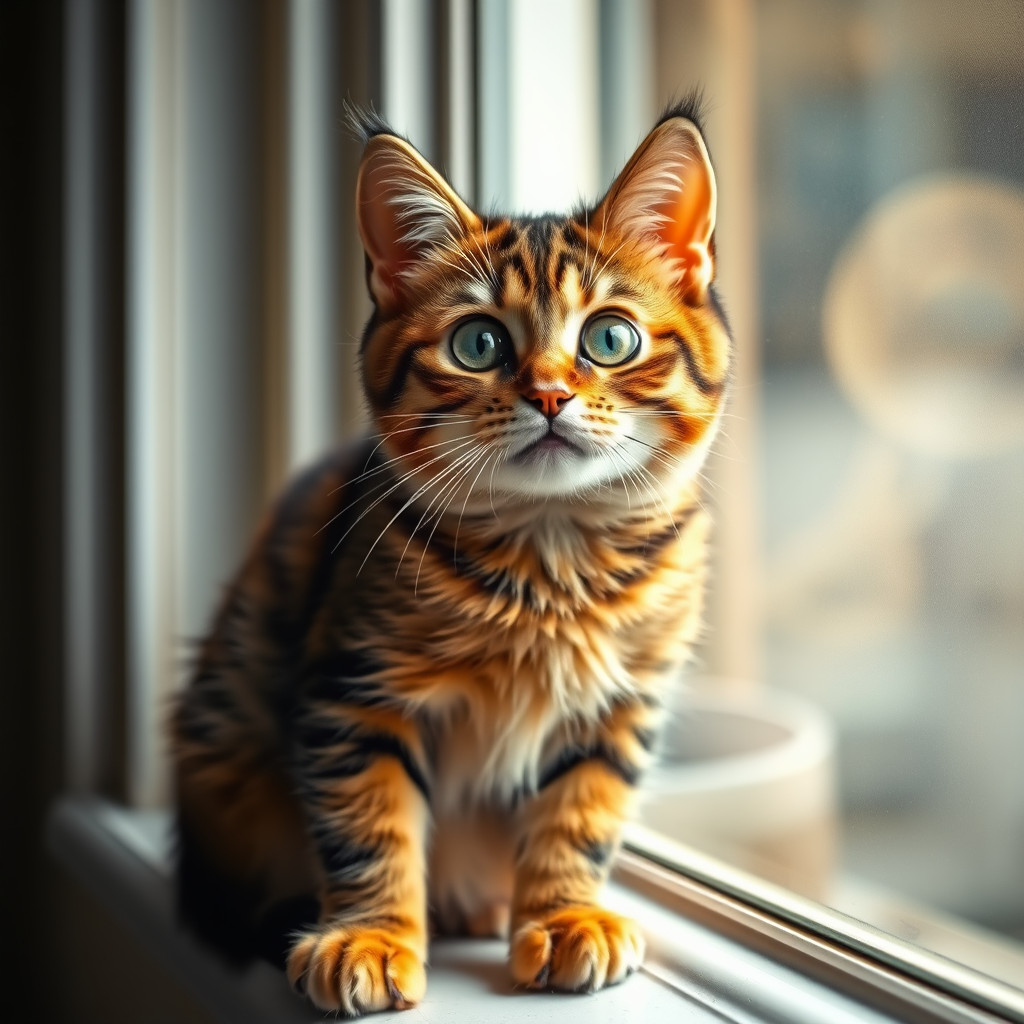

In [10]:
agent = CodeAgent(tools=[image_generation_tool, final_answer], model=model, stream_outputs=True)
agent.run("Make a picture of a cat")